# Developing an AI application

Going forward, AI algorithms will be incorporated into more and more everyday applications. For example, we might want to include an image classifier in a smart phone app. To do this, we'd use a deep learning model trained on hundreds of thousands of images as part of the overall application architecture. A large part of software development in the future will be using these types of models as common parts of applications.

In this project, we'll train an image classifier to recognize different species of flowers. We can imagine using something like this in a phone app that tells us the name of the flower our camera is looking at. In practice we'd train this classifier, then export it for use in our application. We'll be using a dataset of 102 flower categories.
The project is broken down into multiple steps:

* Load and preprocess the image dataset
* Train the image classifier on the dataset
* Use the trained classifier to predict image content



In [1]:
# Imports here
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('ggplot')



## Load the data

Here we'll use `torchvision` to load the data. The dataset is split into three parts, training, validation, and testing. For the training, we'll want to apply transformations such as random scaling, cropping, and flipping. This will help the network generalize leading to better performance. we'll also need to make sure the input data is resized to 224x224 pixels as required by the pre-trained networks.

The validation and testing sets are used to measure the model's performance on data it hasn't seen yet. For this we don't want any scaling or rotation transformations, but we'll need to resize then crop the images to the appropriate size.

The pre-trained networks we'll use were trained on the ImageNet dataset where each color channel was normalized separately. For all three sets we'll need to normalize the means and standard deviations of the images to what the network expects. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`, calculated from the ImageNet images.  These values will shift each color channel to be centered at 0 and range from -1 to 1.


In [2]:
import os
import requests
import tarfile

URL = "https://s3.amazonaws.com/content.udacity-data.com/nd089/flower_data.tar.gz"
DATA_DIR = "data"
TAR_PATH = os.path.join(DATA_DIR, "flower_data.tar.gz")
EXTRACT_DIR = os.path.join(DATA_DIR, "flowers")

os.makedirs(DATA_DIR, exist_ok=True)

# Download
if not os.path.exists(TAR_PATH):
    print("Downloading dataset...")
    response = requests.get(URL, stream=True)
    response.raise_for_status()
    with open(TAR_PATH, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print("Download complete.")
else:
    print("Tar file already exists, skipping download.")

# Extract
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset...")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with tarfile.open(TAR_PATH, mode="r:gz") as tar:
        tar.extractall(path=EXTRACT_DIR)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")


Download complete.
Extracting dataset...


/tmp/ipython-input-1806008862.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_DIR)


Extraction complete.


In [3]:
# Download json file from my Google cloud

json_url = "https://storage.googleapis.com/data_files_soliman/udacity/Python_AI/cat_to_name.json"

!wget -O cat_to_name.json {json_url}

--2025-12-14 15:29:16--  https://storage.googleapis.com/data_files_soliman/udacity/Python_AI/cat_to_name.json
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2218 (2.2K) [application/json]
Saving to: ‘cat_to_name.json’

cat_to_name.json    100%[===================>]   2.17K  --.-KB/s    in 0s      

2025-12-14 15:29:17 (33.8 MB/s) - ‘cat_to_name.json’ saved [2218/2218]



In [4]:
data_dir = 'data/flowers'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'
test_dir = data_dir + '/test'

In [5]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomRotation(30),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, transform=data_transforms['train']),
    'valid': datasets.ImageFolder(valid_dir, transform=data_transforms['valid']),
    'test': datasets.ImageFolder(test_dir, transform=data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=64, shuffle=True),
    'valid': DataLoader(image_datasets['valid'], batch_size=64),
    'test': DataLoader(image_datasets['test'], batch_size=64)
}

### Label mapping

We'll also need to load in a mapping from category label to category name. We can find this in the file `cat_to_name.json`. It's a JSON object which we can read in with the [`json` module](https://docs.python.org/2/library/json.html). This will give us a dictionary mapping the integer encoded categories to the actual names of the flowers.

In [6]:
import json

with open('cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f)

len(cat_to_name)

102

# Building and training the classifier

Now that the data is ready, it's time to build and train the classifier. As usual, we should use one of the pretrained models from `torchvision.models` to get the image features. Build and train a new feed-forward classifier using those features.


In [7]:
from collections import OrderedDict

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the pre-trained model
model = models.vgg16(pretrained=True)

# Freeze parameters so we don't backprop through them
for param in model.parameters():
    param.requires_grad = False

# Define a new classifier
# VGG16 input size is 25088
classifier = nn.Sequential(OrderedDict([
                          ('fc1', nn.Linear(25088, 4096)),
                          ('relu', nn.ReLU()),
                          ('dropout', nn.Dropout(0.2)),
                          ('fc2', nn.Linear(4096, 102)),
                          ('output', nn.LogSoftmax(dim=1))
                          ]))

model.classifier = classifier
model.to(device)

# Define criterion and optimizer
criterion = nn.NLLLoss()
# Only train the classifier parameters, feature parameters are frozen
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Training loop
epochs = 3
print_every = 40
steps = 0

print("Training started...")

for epoch in range(epochs):
    running_loss = 0
    for inputs, labels in dataloaders['train']:
        steps += 1
        # Move input and label tensors to the default device
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        logps = model.forward(inputs)
        loss = criterion(logps, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if steps % print_every == 0:
            valid_loss = 0
            accuracy = 0
            model.eval() # Set to evaluation mode
            with torch.no_grad():
                for inputs, labels in dataloaders['valid']:
                    inputs, labels = inputs.to(device), labels.to(device)
                    logps = model.forward(inputs)
                    batch_loss = criterion(logps, labels)

                    valid_loss += batch_loss.item()

                    # Calculate accuracy
                    ps = torch.exp(logps)
                    top_p, top_class = ps.topk(1, dim=1)
                    equals = top_class == labels.view(*top_class.shape)
                    accuracy += torch.mean(equals.type(torch.FloatTensor)).item()

            print(f"Epoch {epoch+1}/{epochs}.. "
                  f"Train loss: {running_loss/print_every:.3f}.. "
                  f"Validation loss: {valid_loss/len(dataloaders['valid']):.3f}.. "
                  f"Validation accuracy: {accuracy/len(dataloaders['valid']):.3f}")

            running_loss = 0
            model.train() # Set back to training mode

print("Training finished.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 201MB/s]


Training started...
Epoch 1/3.. Train loss: 5.521.. Validation loss: 1.622.. Validation accuracy: 0.577
Epoch 1/3.. Train loss: 1.769.. Validation loss: 0.974.. Validation accuracy: 0.733
Epoch 2/3.. Train loss: 0.512.. Validation loss: 0.721.. Validation accuracy: 0.809
Epoch 2/3.. Train loss: 1.046.. Validation loss: 0.612.. Validation accuracy: 0.827
Epoch 2/3.. Train loss: 0.998.. Validation loss: 0.586.. Validation accuracy: 0.839
Epoch 3/3.. Train loss: 0.747.. Validation loss: 0.538.. Validation accuracy: 0.868
Epoch 3/3.. Train loss: 0.877.. Validation loss: 0.513.. Validation accuracy: 0.856
Training finished.


## Testing our network

It's good practice to test our trained network on test data, images the network has never seen either in training or validation.

In [8]:
test_loss = 0
accuracy = 0
model.eval()

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        logps = model.forward(inputs)
        batch_loss = criterion(logps, labels)

        test_loss += batch_loss.item()

        # Calculate accuracy
        ps = torch.exp(logps)
        top_p, top_class = ps.topk(1, dim=1)
        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor)).item()

print(f"Test accuracy: {accuracy/len(dataloaders['test']):.3f}")

Test accuracy: 0.851


## Save the checkpoint

Now that our network is trained, save the model so we can load it later for making predictions.

In [9]:
model.class_to_idx = image_datasets['train'].class_to_idx

checkpoint = {
    'input_size': 25088,
    'output_size': 102,
    'structure': 'vgg16',
    'classifier': model.classifier,
    'state_dict': model.state_dict(),
    'class_to_idx': model.class_to_idx
}

torch.save(checkpoint, 'checkpoint.pth')
print("Checkpoint saved.")

Checkpoint saved.


## Loading the checkpoint

At this point it's good to write a function that can load a checkpoint and rebuild the model. That way we can come back to this project and keep working on it without having to retrain the network.

In [10]:
def load_checkpoint(filepath):
    checkpoint = torch.load(filepath, weights_only=False)

    # Rebuild the model architecture (assuming VGG16)
    model = models.vgg16(pretrained=True)

    # Freeze parameters
    for param in model.parameters():
        param.requires_grad = False

    # Load the classifier and state dictionary
    model.classifier = checkpoint['classifier']
    model.load_state_dict(checkpoint['state_dict'])
    model.class_to_idx = checkpoint['class_to_idx']

    return model

# Load the model to verify
model = load_checkpoint('checkpoint.pth')
print("Model loaded.")

Model loaded.


# Inference for classification



In [11]:

def process_image(image_path):
    ''' Scales, crops, and normalizes a PIL image for a PyTorch model,
        returns an Numpy array
    '''
    # Open the image
    img = Image.open(image_path)

    # 1. Resize: shortest side to 256, keeping aspect ratio
    if img.size[0] > img.size[1]:
        img.thumbnail((10000, 256))
    else:
        img.thumbnail((256, 10000))

    # 2. Crop: center 224x224
    left = (img.width - 224) / 2
    bottom = (img.height - 224) / 2
    right = left + 224
    top = bottom + 224
    img = img.crop((left, bottom, right, top))

    # 3. Normalize: Convert to 0-1 float and normalize
    # Convert to numpy array first
    np_img = np.array(img) / 255
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    np_img = (np_img - mean) / std

    # 4. Transpose: PyTorch expects color channel first
    np_img = np_img.transpose((2, 0, 1))

    return np_img



To check our work, the function below converts a PyTorch tensor and displays it in the notebook. If our `process_image` function works, running the output through this function should return the original image (except for the cropped out portions).

In [12]:
def imshow(image, ax=None, title=None):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    # PyTorch tensors assume the color channel is the first dimension
    # but matplotlib assumes is the third dimension
    image = image.numpy().transpose((1, 2, 0))

    # Undo preprocessing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean

    # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    image = np.clip(image, 0, 1)

    ax.imshow(image)

    return ax

## Class Prediction

Once we can get images in the correct format, it's time to write a function for making predictions with our model. A common practice is to predict the top 5 or so (usually called top-$K$) most probable classes. We'll want to calculate the class probabilities then find the $K$ largest values.


In [13]:
def predict(image_path, model, topk=5):
    ''' Predict the class (or classes) of an image using a trained deep learning model.
        Returns: topk probabilities (list), topk class indices (list)
    '''

    # Set model to evaluation mode and move to device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # 1. Pre-process the image
    img = process_image(image_path)

    # Convert numpy array to torch tensor
    img_tensor = torch.from_numpy(img).type(torch.FloatTensor)

    # Add batch dimension (model expects a batch of images, even if it's just one)
    img_tensor = img_tensor.unsqueeze(0)

    # Move tensor to the same device as the model
    img_tensor = img_tensor.to(device)

    # 2. Inference (Forward pass)
    with torch.no_grad():
        # Get log probabilities
        logps = model.forward(img_tensor)

        # Convert log probabilities to actual probabilities
        ps = torch.exp(logps)

        # Get the top K probabilities and their indices
        top_p, top_class = ps.topk(topk, dim=1)

    # 3. Convert results back to standard Python lists

    # Convert tensors to numpy arrays, then to lists
    # [0] is used to extract the values from the single batch dimension
    top_p = top_p.cpu().numpy()[0].tolist()
    top_class = top_class.cpu().numpy()[0].tolist()

    # 4. Map indices back to class labels (keys from the original training dataset)
    # The 'top_class' list contains indices (0-101). We need to map them back
    # to the string folder names (e.g., '70', '3') using the model's class_to_idx.
    idx_to_class = {v: k for k, v in model.class_to_idx.items()}
    top_classes = [idx_to_class[c] for c in top_class]

    return top_p, top_classes

## Sanity Checking

Now that we can use a trained model for predictions, check to make sure it makes sense. Even if the testing accuracy is high, it's always good to check that there aren't obvious bugs. Use `matplotlib` to plot the probabilities for the top 5 classes as a bar graph, along with the input image.


In [14]:
test_dir

'data/flowers/test'

In [15]:
# # Select a random image from the test set
# image_path = test_dir + '/10/image_07104.jpg'


In [22]:
# Random image by code

import random

# 1. Get a list of all class folders
class_folders = os.listdir(test_dir)
# print(class_folders)
class_folders = [d for d in class_folders if os.path.isdir(os.path.join(test_dir, d))]

# 2. Select a random class folder
random_class = random.choice(class_folders)

# 3. Get the list of images inside that random class folder
image_files = os.listdir(os.path.join(test_dir, random_class))

# 4. Select a random image file
random_image_file = random.choice(image_files)

# 5. Construct the full image path
image_path = os.path.join(test_dir, random_class, random_image_file)
image_path

'data/flowers/test/69/image_05994.jpg'

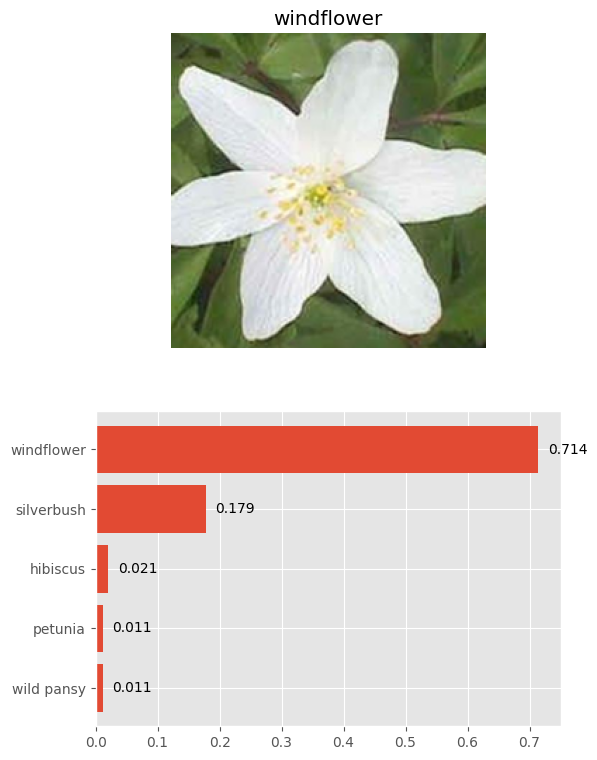

In [23]:

# Run prediction
probs, classes = predict(image_path, model)

# Map classes to flower names
flower_names = [cat_to_name[c] for c in classes]

# Plotting
fig, (ax1, ax2) = plt.subplots(figsize=(6, 9), nrows=2)

# Image subplot
ax1.axis('off')
ax1.set_title(flower_names[0])
img = process_image(image_path)
imshow(torch.from_numpy(img), ax=ax1)

# Bar chart subplot
y_pos = np.arange(len(flower_names))
ax2.barh(y_pos, probs)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(flower_names)
ax2.invert_yaxis()  # Highest probability on top

for i, prob in enumerate(probs):
    ax2.text(prob + 0.015, i, f'{prob:.3f}',
             va='center', ha='left')


plt.show()

* **The classification was tested and approved succefully.**